In [1]:
import torch
from torch import nn
import torchvision
import os
import numpy
import random
import torch.nn.functional as F
from torchinfo import summary
device = 'cuda' if torch.cuda.is_available() else 'cpu'
B = 32
image_size = 32
# prepare dataset 
preprocess = torchvision.transforms.Compose([
    torchvision.transforms.Resize(size=image_size),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.0, ], std=[1.0, ])
              ])
MNIST_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=preprocess)

train_loader = torch.utils.data.DataLoader(
    dataset=MNIST_dataset,
    batch_size=B,
    shuffle=True,
    num_workers=os.cpu_count()
)



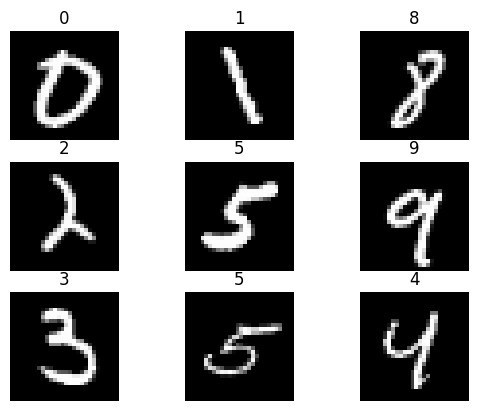

In [2]:
# Visualize the dataset

import matplotlib.pyplot as plt
from pathlib import Path

num_images = 9
nrows, ncols = 3, 3

fig, axes = plt.subplots(ncols=ncols, nrows=nrows)
axes = axes.flatten()
for i in range(num_images):
    rand_ind = random.randint(0, len(MNIST_dataset.data)-1)
    axes[i].imshow(MNIST_dataset.data[rand_ind].cpu().numpy(), cmap='gray')
    axes[i].set_title(MNIST_dataset.targets[rand_ind].item())
    axes[i].axis('off')

plt.show()

In [3]:
# lets build a uet model for DDPM
import math

# Time embedding
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, D):
        super().__init__()
        self.D = D

    def forward(self, t: torch.Tensor):  # (B,)
        half = self.D // 2

        # Make freqs on the same device + dtype as t
        freqs = torch.arange(0, half, device=t.device, dtype=torch.float32)  # (half,)

        # Use a scalar constant (Python float) but keep freqs as float32/float16 etc.
        freqs = torch.exp(-math.log(10000) * freqs / (half - 1))      # (half,)

        args = freqs[None, :] * t[:, None]                               # (B, half)
        sin, cos = torch.sin(args), torch.cos(args)                      # (B, half)

        emb = torch.stack((sin, cos), dim=-1)                            # (B, half, 2)
        emb = emb.view(t.size(0), self.D)                                # (B, D)
        return emb

class ResBlock(nn.Module):
    def __init__(self, in_dim : int, out_dim : int, t_dim : int):
        super().__init__()
        self.norm1 = nn.GroupNorm(num_groups=8, num_channels=in_dim)
        self.conv1 = nn.Conv2d(in_channels=in_dim, out_channels=out_dim, kernel_size=3, padding=1)
        self.norm2 = nn.GroupNorm(num_groups=8, num_channels=out_dim)
        self.conv2 = nn.Conv2d(in_channels=out_dim, out_channels=out_dim, kernel_size=3, padding=1)
        self.time_proj = nn.Linear(in_features=t_dim, out_features=out_dim)
        self.skip = nn.Conv2d(in_channels=in_dim, out_channels=out_dim, kernel_size=1) if in_dim != out_dim else nn.Identity()

    def forward(self, 
                x : torch.Tensor, #(B, C, H, W)
                t_emb : torch.Tensor, #(B, D_t)
                ) : 
        h = self.conv1(F.silu(self.norm1(x))) # (B, out_dim, H, W)
        h = h + self.time_proj(t_emb).unsqueeze(-1).unsqueeze(-1) # (B, out_dim, H, W)
        h = self.conv2(F.silu(self.norm2(h))) # (B, out_dim, H, W)
        h = h + self.skip(x)
        return h
    
class UNetDiffusion(nn.Module):
    def __init__(self, in_channel:int, base:int, t_dim:int):
        super().__init__()

        self.t_embedding = nn.Sequential(
            SinusoidalTimeEmbedding(D=t_dim),
            nn.Linear(in_features=t_dim, out_features=t_dim),
            nn.SiLU(),
            nn.Linear(in_features=t_dim, out_features=t_dim)
            )
        self.in_conv = nn.Conv2d(in_channels=in_channel, out_channels=base, kernel_size=3, padding=1)
        
        self.res1 = ResBlock(in_dim=base, out_dim=base, t_dim=t_dim)
        self.down1 = nn.Conv2d(in_channels=base, out_channels=base, kernel_size=4, stride=2, padding=1)
        self.res2 = ResBlock(in_dim=base, out_dim=2*base,t_dim=t_dim)
        self.down2 = nn.Conv2d(in_channels=2*base, out_channels=2*base, kernel_size=4, stride=2, padding=1)

        self.res3 = ResBlock(in_dim=2*base, out_dim=4*base, t_dim=t_dim)

        self.res4 = ResBlock(in_dim=4*base, out_dim=4*base, t_dim=t_dim)
        self.res5 = ResBlock(in_dim=4*base, out_dim=4*base, t_dim=t_dim)

        self.up2 = nn.ConvTranspose2d(in_channels=4*base, out_channels=4*base, kernel_size=4, stride=2, padding=1)
        self.res6 = ResBlock(in_dim=4*base + 2*base, out_dim=2*base, t_dim=t_dim)
        self.up1 = nn.ConvTranspose2d(in_channels=2*base, out_channels=2*base, kernel_size=4, stride=2, padding=1)
        self.res7 = ResBlock(in_dim=2*base + base, out_dim=base, t_dim=t_dim)

        self.out_norm = nn.GroupNorm(8, num_channels=base)
        self.out_conv = nn.Conv2d(in_channels=base, out_channels=in_channel, kernel_size=3, padding=1)

    def forward(self, 
                x : torch.Tensor,    # (B, in_channel, H, W)
                t : torch.Tensor, # (B, )
                ):
        t_emb = self.t_embedding(t) # (B, t_dim)
        x = self.in_conv(x) # (B, base, H, W)
        s1 = self.res1(x, t_emb) # (B, base, H, W)

        x = self.down1(s1) # (B, base, H/2, W/2)
        s2 = self.res2(x, t_emb) # (B, 2*base, H/2, W/2)
        
        x = self.down2(s2) # (B, 2*base, H/4, W/4)
        
        x = self.res5(self.res4(self.res3(x, t_emb), t_emb), t_emb) # (B, 4*base, H/4, W/4)

        x = self.up2(x) # (B, 4*base, H/2, W/2)

        x = self.res6(torch.cat((x, s2), dim=1), t_emb) # (B, 2*base, H/2, W/2)

        x = self.up1(x) # (B, 2*base, H, W)

        x = self.res7(torch.cat((x, s1), dim=1), t_emb) # (B, base, H, W)

        x = self.out_norm(x) # (B, base, H, W)
        return self.out_conv(F.silu(x)) # (B, in_channel, H, W)
    

summary(UNetDiffusion(in_channel=1, base=64, t_dim=256),     
        input_data=(
            torch.randn(B, 1, image_size, image_size),
            torch.randint(0, 1000, (B,), dtype=torch.int64)
    ))

Layer (type:depth-idx)                   Output Shape              Param #
UNetDiffusion                            [32, 1, 32, 32]           --
├─Sequential: 1-1                        [32, 256]                 --
│    └─SinusoidalTimeEmbedding: 2-1      [32, 256]                 --
│    └─Linear: 2-2                       [32, 256]                 65,792
│    └─SiLU: 2-3                         [32, 256]                 --
│    └─Linear: 2-4                       [32, 256]                 65,792
├─Conv2d: 1-2                            [32, 64, 32, 32]          640
├─ResBlock: 1-3                          [32, 64, 32, 32]          --
│    └─GroupNorm: 2-5                    [32, 64, 32, 32]          128
│    └─Conv2d: 2-6                       [32, 64, 32, 32]          36,928
│    └─Linear: 2-7                       [32, 64]                  16,448
│    └─GroupNorm: 2-8                    [32, 64, 32, 32]          128
│    └─Conv2d: 2-9                       [32, 64, 32, 32]         

In [4]:
# # Now let's start training


# from tqdm.auto import tqdm
# model = UNetDiffusion(in_channel=1, base=64, t_dim=256)
# model.to(device)
# optim = torch.optim.Adam(model.parameters(), lr=1e-4)
# epochs = 100


# beta_start = 1e-4
# beta_end = 0.02
# time_steps = 1000
# betas = torch.linspace(beta_start, beta_end, time_steps, dtype=torch.float32, device=device)
# alphas = 1.0 - betas
# alphas_cumprod = torch.cumprod(alphas,dim=0)
# sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
# sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 -  alphas_cumprod)


# print('Start Training')
# for epoch in tqdm(range(epochs)):
#     model.train()
#     for data, _ in train_loader:
#         imgs = data.to(device)
#         noise = torch.randn_like(imgs, device=device)
#         t = torch.randint(0, time_steps, size=(imgs.size(0),), device=device, dtype=torch.int64)
#         noisy_imgs = sqrt_alphas_cumprod[t, None, None, None] * imgs + sqrt_one_minus_alphas_cumprod[t, None, None, None] * noise
#         denoise = model(noisy_imgs, t)
#         loss = F.mse_loss(noise, denoise)
#         optim.zero_grad()
#         loss.backward()
#         optim.step()    
    
#     print(f"Step {epoch}... Loss {loss.item()}")

# save_path = Path.cwd() / "models" / "UnetDiff.pth"
# save_path.parent.mkdir(parents=True, exist_ok=True)  # ensure folder exists

# torch.save(model.state_dict(), save_path)
# print(f'Model saved to {save_path.as_posix()}')




In [12]:
import torch
from pathlib import Path

# Now let's do the inference
test_model =  UNetDiffusion(in_channel=1, base=64, t_dim=256)
weights = torch.load(Path('models/UnetDiff.pth'))
test_model.load_state_dict(weights)
test_model.to(device)
beta_min = 1e-4
beta_max = 0.02
time_steps = 1000
betas = torch.linspace(beta_min, beta_max, time_steps, device=device)
alphas = 1 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

sample = torch.randn(B, 1, image_size, image_size, device=device)
test_model.eval()
with torch.no_grad():
    for t in reversed(range(time_steps)):
        t_tensor = torch.ones(B, device=device, dtype=torch.int64) * t
        if t > 0:
            z = torch.randn_like(sample, device=device)
        else:
            z = 0
        denoise = test_model(sample, t_tensor)
        sample = (1.0 / torch.sqrt(alphas[t])) * (sample - (1.0-alphas[t])/ torch.sqrt(1-alphas_cumprod[t]) * denoise) + torch.sqrt(betas[t]) * z



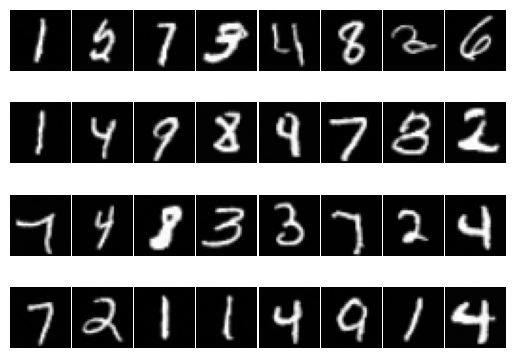

In [13]:
import matplotlib.pyplot as plt

figure, axes = plt.subplots(nrows=4, ncols=8    ,gridspec_kw={"wspace": 0.02, "hspace": 0.0}
)
axes = axes.flatten()
for i in range(B):
    axes[i].imshow(sample[i].permute(1,2,0).cpu().numpy(), cmap='gray')
    axes[i].axis('off')

plt.show()